# Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Name:** Akshat Garg  

**Registration Number:** 23BCE10641

**Application Number:** IN26011052

**Batch Number:** 1A

**Email ID:** akshat.23bce10641@vitbhopal.ac.in 

In [1]:
import os
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
!pip install -q kaggle

os.environ['KAGGLE_USERNAME'] = input("Kaggle Username: ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Kaggle API Key: ")

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files('uciml/breast-cancer-wisconsin-data', path='.', unzip=True)

df = pd.read_csv('data.csv')
df.head()

Kaggle Username:  AkshatGarg2005
Kaggle API Key:  ········


Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Identify Target Variable and Numerical Features
target_var = 'diagnosis'
num_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print("Target Variable:", target_var)
print("Number of Numerical Features:", len(num_features))

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
df.describe()

Target Variable: diagnosis
Number of Numerical Features: 32

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [4]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop unnecessary columns ('id' and empty 'Unnamed: 32')
df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Encode target variable: Malignant (M) -> 1, Benign (B) -> 0
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize feature values (critical for KNN distance metrics)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nX_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

Missing values per column:
Unnamed: 32    569
dtype: int64

X_train shape: (455, 30)
X_test shape: (114, 30)


In [5]:
# Task 3: Train KNN Classifier with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict class labels for the test dataset
y_pred = knn.predict(X_test_scaled)

Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1-Score : 0.9383


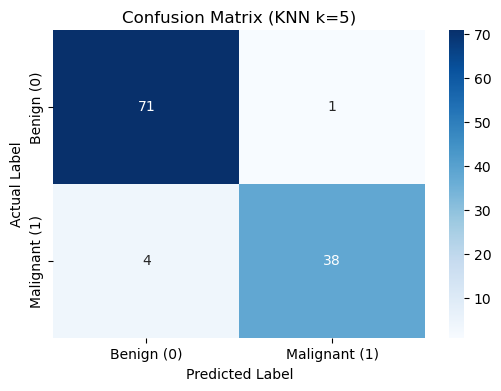

In [6]:
# Task 4: Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (KNN k=5)')
plt.show()

In [7]:
print("--- Model Observations ---")
print("1. The KNN classifier (k=5) achieved a high overall accuracy of 95.61% and an F1-score of 0.9383 on the test set.")
print("2. Precision reached 97.44%, incorrectly classifying only 1 benign tumor as malignant (1 false positive).")
print("3. Recall stood at 90.48%, correctly identifying 38 out of 42 malignant cases, with 4 false negatives.")

--- Model Observations ---
1. The KNN classifier (k=5) achieved a high overall accuracy of 95.61% and an F1-score of 0.9383 on the test set.
2. Precision reached 97.44%, incorrectly classifying only 1 benign tumor as malignant (1 false positive).
3. Recall stood at 90.48%, correctly identifying 38 out of 42 malignant cases, with 4 false negatives.


## Conclusion

This project implemented a K-Nearest Neighbors (KNN) classifier ($k=5$) on the Breast Cancer Wisconsin Diagnostic dataset to predict tumor malignancy. Key findings demonstrate that diagnostic cell attributes effectively differentiate between benign and malignant tumors, achieving an overall classification accuracy of 95.61% and an F1-score of 0.9383. 

Feature scaling using `StandardScaler` is critical for KNN because the algorithm calculates distance metrics (such as Euclidean distance) between data points. Features with larger raw numerical scales (e.g., `area_mean`) would otherwise completely dominate the distance metric over smaller-scale features (e.g., `smoothness_mean`), biasing the neighbors' majority vote. 

A key limitation of the KNN algorithm is its high computational complexity during inference. Because KNN is a non-parametric, lazy learner, it requires computing distances to every training instance for each query prediction, making it slow and memory-intensive as datasets scale.